# scitex.clew -- Cryptographic Verification for Research

Clew builds a SHA-256 hash-chain DAG that links manuscript claims
back to source data through every intermediate computation step.
Named after Ariadne's thread -- the clew that lets you trace your
way back through the labyrinth.

Every `stx.clew.run()` records inputs, outputs, code, and environment
into an append-only hash chain. Later, anyone can verify that a
claimed result was actually produced from the stated data and code.

In [1]:
import scitex as stx

## Project Verification Status

`stx.clew.status()` gives a git-status-like overview:
which runs are verified, which have been tampered with, and which are pending.

In [2]:
# Shows verified/tampered/pending runs across the project
stx.clew.status()

{'verified_count': 113,
 'mismatch_count': 4,
 'missing_count': 17,
 'mismatched': [{'session_id': '2026Y-03M-18D-16h25m48s_MwYb',
   'files': ['/home/ywatanabe/proj/scitex-python/examples/01_session_out/sine.png',
    '/home/ywatanabe/proj/scitex-python/examples/01_session.py']},
  {'session_id': '2026Y-03M-18D-16h17m52s_XtOn',
   'files': ['/home/ywatanabe/proj/scitex-python/examples/01_session.py']},
  {'session_id': '2026Y-03M-18D-16h17m19s_hjwG',
   'files': ['/home/ywatanabe/proj/scitex-python/examples/01_session.py']},
  {'session_id': '2026Y-03M-18D-16h16m19s_t95u',
   'files': ['/home/ywatanabe/proj/scitex-python/examples/01_session.py']}],
 'missing': [{'session_id': '2026Y-03M-18D-17h01m45s_OhbV',
   'files': ['/home/ywatanabe/.cache/tmp/tmp8xf22yju/test_script.py']},
  {'session_id': '2026Y-03M-18D-17h01m39s_OhbV',
   'files': ['/home/ywatanabe/.cache/tmp/tmpi9c_0l93/test_script.py']},
  {'session_id': '2026Y-03M-14D-17h22m06s_OhbV',
   'files': ['/home/ywatanabe/.cache/tmp

## List Tracked Runs

Each `stx.clew.run()` is recorded with a unique hash. List recent runs to inspect the chain.

In [3]:
# Show the 5 most recent tracked runs
stx.clew.list_runs(limit=5)

[{'session_id': 'timing_test',
  'script_path': '',
  'script_hash': None,
  'started_at': '2026-03-18T17:02:21.063528',
  'finished_at': '2026-03-18T17:02:21.175885',
  'status': 'success',
  'exit_code': 0,
  'parent_session': None,
  'combined_hash': 'e3b0c44298fc1c149afbf4c8996fb924',
  'metadata': None},
 {'session_id': 'exp_001',
  'script_path': '',
  'script_hash': None,
  'started_at': '2026-03-18T17:02:21.028466',
  'finished_at': '2026-03-18T17:02:21.043141',
  'status': 'success',
  'exit_code': 0,
  'parent_session': None,
  'combined_hash': 'e3b0c44298fc1c149afbf4c8996fb924',
  'metadata': None},
 {'session_id': 'persistent',
  'script_path': '',
  'script_hash': None,
  'started_at': '2026-03-18T17:02:20.998924',
  'finished_at': None,
  'status': 'running',
  'exit_code': None,
  'parent_session': None,
  'combined_hash': None,
  'metadata': None},
 {'session_id': 'test',
  'script_path': '',
  'script_hash': None,
  'started_at': '2026-03-18T17:02:20.965385',
  'finish

## Verify a Single File's Provenance

`stx.clew.chain()` traces a file back through the hash chain to its source data,
showing every intermediate step.

In [4]:
# Trace provenance of an output file back to its source
# stx.clew.chain("path/to/output.csv")

# In a real project with @stx.session runs, this returns
# a ChainVerification showing every step from output -> source
print("chain() traces: output -> processing script -> input data")

chain() traces: output -> processing script -> input data


## Verify Full DAG

`stx.clew.dag()` verifies the entire directed acyclic graph of runs,
checking that every hash matches and no intermediate files were altered.

In [5]:
# Verify all runs in the project DAG
stx.clew.dag()

DAGVerification(target_files=[], runs=[], edges=[], status=<VerificationStatus.UNKNOWN: 'unknown'>, topological_order=[])

## Register and Verify Claims

Claims are human-readable assertions (e.g., "accuracy > 90%") that are
cryptographically bound to a specific run output. Reviewers can verify
that the claim matches the actual computed result.

In [6]:
# Register a claim tied to a manuscript assertion
# stx.clew.add_claim(
#     file_path="paper/main.tex",
#     claim_type="statistic",
#     line_number=142,
#     claim_value="t(58) = 2.34, p = .021",
#     source_session="2026-03-18_14-30-00_Z5MR",
#     source_file="results/stats.csv",
# )
#
# Verify a specific claim
# stx.clew.verify_claim(claim_id="...")
print("add_claim() signature: file_path, claim_type, line_number, claim_value, source_file, source_session")

add_claim() signature: file_path, claim_type, line_number, claim_value, source_file, source_session


## Visualize Provenance DAG

Generate a Mermaid diagram showing the full provenance graph.
With `claims=True`, manuscript claims are overlaid on the DAG.

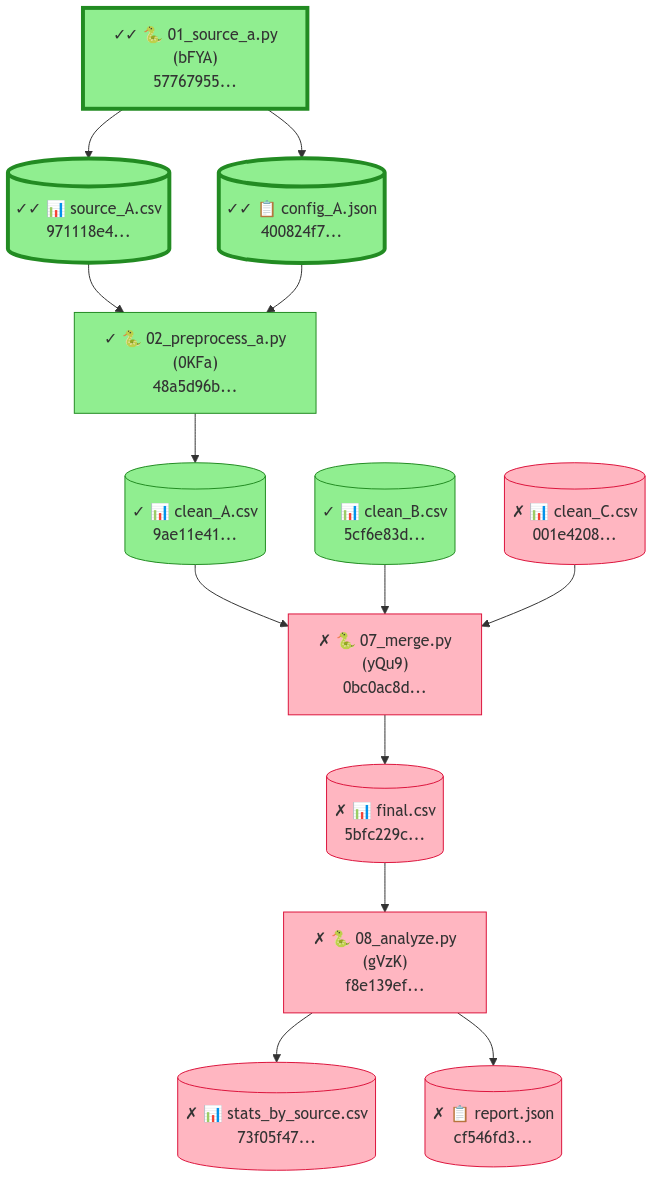

In [7]:
# Generate Mermaid diagram of the provenance DAG with claims
# stx.clew.mermaid(claims=True)

# Display the example DAG visualization
from IPython.display import Image
Image("../docs/clew-dag.png", width=400)

## Three Verification Modes

| Mode | Command | What it checks |
|------|---------|----------------|
| **Project** | `stx.clew.status()` | All runs in the project -- git-status-like overview |
| **File** | `stx.clew.chain("output.csv")` | Single file's full provenance back to source data |
| **Claim** | `stx.clew.verify_claim("output.csv")` | A manuscript assertion is still backed by unchanged data |

All three modes use the same underlying SHA-256 hash chain.
The DAG can be exported as Mermaid for inclusion in papers or reviews.